# 01 - Data Exploration & Profiling

Deep dive into Polymarket data distributions, time series, top entities, and market characteristics.

**Outputs**: `output/exploration_summary.json`, `output/monthly_volume.parquet`, `output/top_markets.parquet`

**Approach**: DuckDB for streaming aggregations, Polars for medium results, pandas only for final plotting

In [1]:
import duckdb
import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
import json
import matplotlib.pyplot as plt

DATA_DIR = Path('../Polymarket_data/data')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# DuckDB connection with optimizations
con = duckdb.connect()
con.execute("SET threads=1")
con.execute("SET enable_progress_bar=false")

# Load markets (small enough for Polars)
markets_df = pl.scan_parquet(str(DATA_DIR / 'markets.parquet')).collect()

print('Data loaded')

Data loaded


In [2]:
# ============================================================
# 1. TEMPORAL ANALYSIS - Monthly volume from quant via DuckDB
# ============================================================
print('Computing monthly volume from quant via DuckDB streaming...')

monthly_combined = con.execute(f"""
    SELECT 
        DATE_TRUNC('month', to_timestamp(timestamp)) as month,
        COUNT(*) as trades,
        SUM(usd_amount) as volume_usd,
        AVG(price) as avg_price,
        COUNT(DISTINCT market_id) as unique_markets,
        COUNT(DISTINCT maker) as unique_makers,
        COUNT(DISTINCT taker) as unique_takers
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    GROUP BY month
    ORDER BY month
""").df()

monthly_combined['month_str'] = monthly_combined['month'].astype(str)

# Save
monthly_combined.to_parquet(OUTPUT_DIR / 'monthly_volume.parquet', index=False)
print(f'Saved monthly volume: {len(monthly_combined)} months')
print(monthly_combined[['month_str', 'trades', 'volume_usd', 'avg_price']].to_string(index=False))

Computing monthly volume from quant via DuckDB streaming...
Saved monthly volume: 45 months
                month_str    trades   volume_usd  avg_price
2022-11-01 00:00:00+01:00        73 6.857100e+02   0.549863
2022-12-01 00:00:00+01:00      1666 1.595868e+05   0.533127
2023-01-01 00:00:00+01:00      3803 5.546146e+05   0.369881
2023-02-01 00:00:00+01:00      7128 1.309936e+06   0.409712
2023-03-01 00:00:00+01:00     24454 5.925601e+06   0.517793
2023-04-01 00:00:00+02:00      9523 1.480771e+06   0.465668
2023-05-01 00:00:00+02:00     12510 3.906557e+06   0.548590
2023-06-01 00:00:00+02:00     16122 3.742100e+06   0.507406
2023-07-01 00:00:00+02:00     13526 3.277450e+06   0.398986
2023-08-01 00:00:00+02:00     22864 4.173215e+06   0.361737
2023-09-01 00:00:00+02:00     12009 1.931674e+06   0.434761
2023-10-01 00:00:00+02:00     24774 4.261789e+06   0.430153
2023-11-01 00:00:00+01:00     24699 3.310371e+06   0.429852
2023-12-01 00:00:00+01:00     22048 3.515351e+06   0.410199
2024-01-

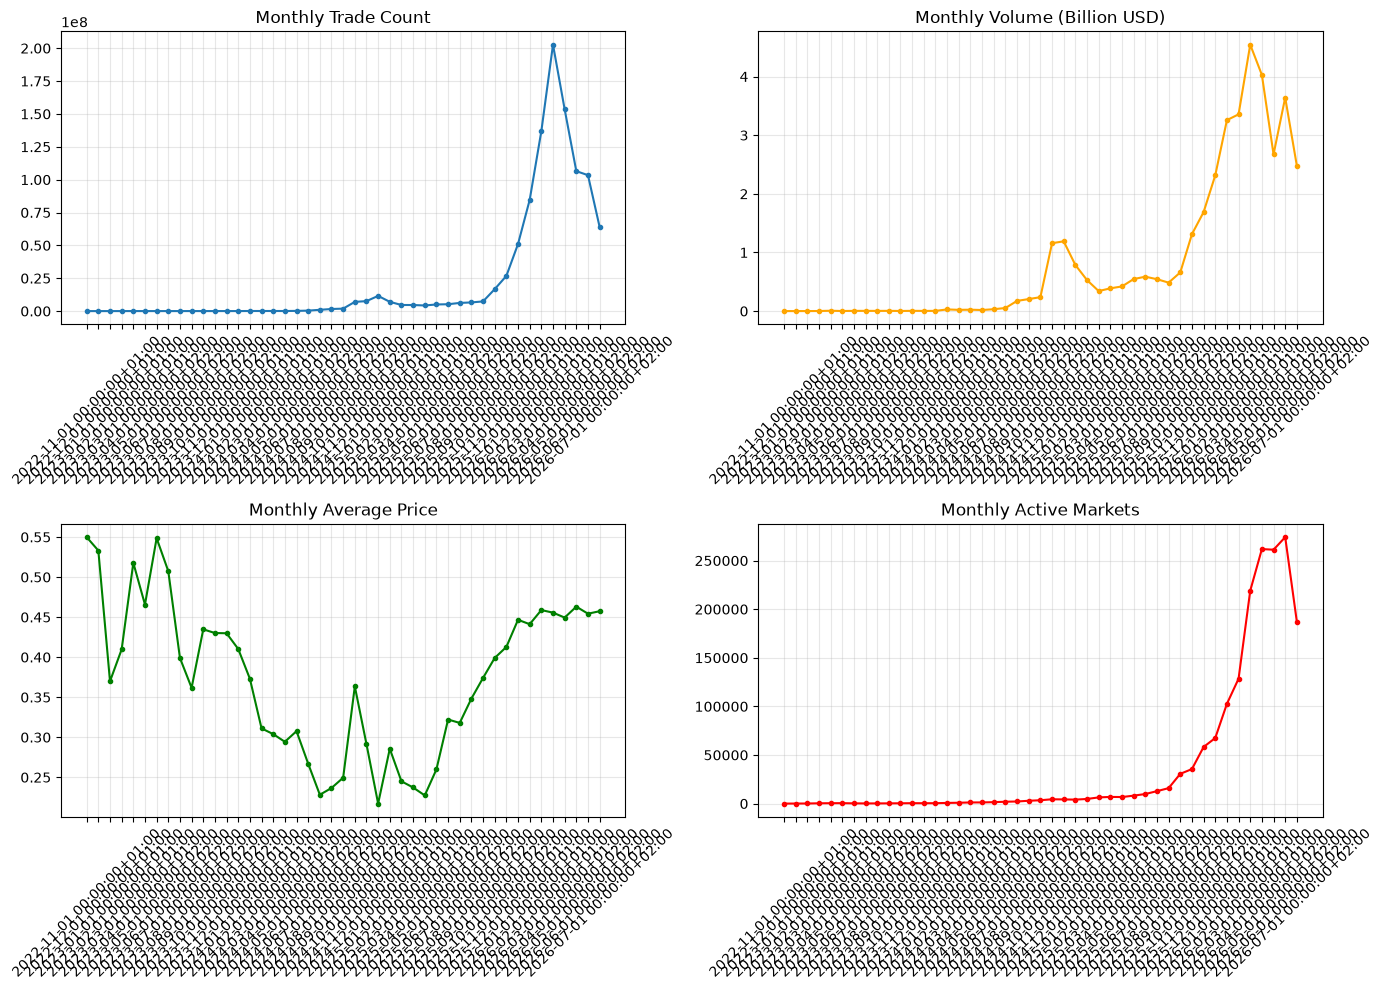

In [3]:
# Plot monthly volume
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trades
axes[0,0].plot(monthly_combined['month_str'], monthly_combined['trades'], marker='o', markersize=3)
axes[0,0].set_title('Monthly Trade Count')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# Volume
axes[0,1].plot(monthly_combined['month_str'], monthly_combined['volume_usd']/1e9, marker='o', markersize=3, color='orange')
axes[0,1].set_title('Monthly Volume (Billion USD)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# Avg price
axes[1,0].plot(monthly_combined['month_str'], monthly_combined['avg_price'], marker='o', markersize=3, color='green')
axes[1,0].set_title('Monthly Average Price')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Unique markets
axes[1,1].plot(monthly_combined['month_str'], monthly_combined['unique_markets'], marker='o', markersize=3, color='red')
axes[1,1].set_title('Monthly Active Markets')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 2. PRICE & VOLUME DISTRIBUTIONS via DuckDB
# ============================================================
print('Computing distributions...')

# Price histogram via DuckDB
price_hist = con.execute(f"""
    SELECT 
        FLOOR(price * 100) / 100 as price_bin,
        COUNT(*) as count
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    WHERE price BETWEEN 0 AND 1
    GROUP BY price_bin
    ORDER BY price_bin
""").df()

# Volume histogram (log scale)
volume_hist = con.execute(f"""
    SELECT 
        FLOOR(LOG10(usd_amount + 1) * 10) / 10 as vol_bin,
        COUNT(*) as count
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    GROUP BY vol_bin
    ORDER BY vol_bin
""").df()

# Price stats
price_stats = con.execute(f"""
    SELECT 
        AVG(price) as mean, 
        STDDEV(price) as std, 
        MIN(price) as min, 
        MAX(price) as max, 
        QUANTILE_CONT(price, 0.5) as median,
        skewness(price) as skew
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
""").df()

volume_stats = con.execute(f"""
    SELECT 
        AVG(usd_amount) as mean, 
        STDDEV(usd_amount) as std, 
        MIN(usd_amount) as min, 
        MAX(usd_amount) as max, 
        QUANTILE_CONT(usd_amount, 0.5) as median
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
""").df()

print(f'Price stats: mean={price_stats["mean"][0]:.4f}, std={price_stats["std"][0]:.4f}, median={price_stats["median"][0]:.4f}, skew={price_stats["skew"][0]:.4f}')
print(f'Volume stats: mean={volume_stats["mean"][0]:.2f}, std={volume_stats["std"][0]:.2f}, median={volume_stats["median"][0]:.2f}')

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(price_hist['price_bin'], price_hist['count'], width=0.01, edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution (0-1)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].bar(volume_hist['vol_bin'], volume_hist['count'], width=0.1, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Log10(Volume + 1) Distribution')
axes[1].set_xlabel('Log10(USD Amount + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Computing distributions...


In [ ]:
# ============================================================
# 3. TOP MARKETS BY VOLUME via DuckDB
# ============================================================
print('Finding top markets...')

top_markets = con.execute(f"""
    SELECT 
        market_id,
        COUNT(*) as trades,
        SUM(usd_amount) as volume_usd
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    GROUP BY market_id
    ORDER BY volume_usd DESC
    LIMIT 50
""").df()

# Join with market metadata
top_markets = top_markets.merge(
    markets_df.select(['id', 'question', 'slug', 'neg_risk', 'volume']).to_pandas(),
    left_on='market_id', right_on='id', how='left'
)

top_markets.to_parquet(OUTPUT_DIR / 'top_markets.parquet', index=False)
print('Top 20 markets by volume:')
print(top_markets.head(20)[['market_id', 'question', 'volume_usd', 'trades', 'neg_risk']].to_string(index=False))

In [ ]:
# ============================================================
# 4. MARKET TYPE ANALYSIS via Polars
# ============================================================
print('=== MARKET TYPE ANALYSIS ===')

print(f'Total markets: {len(markets_df):,}')
print(f'Neg risk markets: {markets_df["neg_risk"].sum():,} ({markets_df["neg_risk"].mean()*100:.1f}%)')
print(f'Closed markets: {markets_df["closed"].sum():,}')
print(f'Active markets: {markets_df["active"].sum():,}')

# Volume by neg_risk
neg_risk_vol = markets_df.group_by('neg_risk').agg(
    pl.col('volume').sum().alias('total_volume'),
    pl.col('volume').mean().alias('avg_volume'),
    pl.count().alias('count')
)
print('\nVolume by neg_risk:')
print(neg_risk_vol.to_pandas().to_string())

# Event-level aggregation
event_stats = markets_df.group_by('event_id').agg(
    pl.count().alias('markets'),
    pl.col('volume').sum().alias('total_volume'),
    pl.col('neg_risk').sum().alias('neg_risk')
).sort('total_volume', descending=True)
print(f'\nTotal events: {len(event_stats):,}')
print('Top 10 events by volume:')
print(event_stats.head(10).to_pandas().to_string())

In [ ]:
# ============================================================
# 5. HOURLY / DAILY PATTERNS via DuckDB
# ============================================================
print('Computing hourly patterns...')

hourly_combined = con.execute(f"""
    SELECT 
        EXTRACT(HOUR FROM to_timestamp(timestamp)) as hour,
        COUNT(*) as trades,
        SUM(usd_amount) as volume
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    GROUP BY hour
    ORDER BY hour
""").df()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(hourly_combined['hour'], hourly_combined['trades']/1e6)
axes[0].set_title('Trades by Hour (UTC)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Million Trades')
axes[0].grid(True, alpha=0.3)

axes[1].bar(hourly_combined['hour'], hourly_combined['volume']/1e9, color='orange')
axes[1].set_title('Volume by Hour (UTC)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Billion USD')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print('Hourly pattern:')
print(hourly_combined.to_string(index=False))

In [ ]:
# ============================================================
# 6. MAKER/TAKER CONCENTRATION (HHI) via DuckDB
# ============================================================
print('Computing concentration metrics...')

# HHI calculation: SUM((volume_i / total_volume)^2)
maker_hhi = con.execute(f"""
    WITH maker_volumes AS (
        SELECT maker, SUM(usd_amount) as volume
        FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
        GROUP BY maker
    ),
    total AS (
        SELECT SUM(volume) as total_vol FROM maker_volumes
    )
    SELECT SUM(POWER(volume / total_vol, 2)) as hhi
    FROM maker_volumes, total
""").df()['hhi'][0]

taker_hhi = con.execute(f"""
    WITH taker_volumes AS (
        SELECT taker, SUM(usd_amount) as volume
        FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
        GROUP BY taker
    ),
    total AS (
        SELECT SUM(volume) as total_vol FROM taker_volumes
    )
    SELECT SUM(POWER(volume / total_vol, 2)) as hhi
    FROM taker_volumes, total
""").df()['hhi'][0]

# Unique counts
unique_counts = con.execute(f"""
    SELECT 
        COUNT(DISTINCT maker) as unique_makers,
        COUNT(DISTINCT taker) as unique_takers
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
""").df()

print(f'Maker HHI: {maker_hhi:.6f}')
print(f'Taker HHI: {taker_hhi:.6f}')
print(f'Unique makers: {unique_counts["unique_makers"][0]:,}')
print(f'Unique takers: {unique_counts["unique_takers"][0]:,}')

# Top 10 makers/takers
top_makers = con.execute(f"""
    SELECT maker, SUM(usd_amount) as volume
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    GROUP BY maker
    ORDER BY volume DESC
    LIMIT 10
""").df()

top_takers = con.execute(f"""
    SELECT taker, SUM(usd_amount) as volume
    FROM read_parquet('{DATA_DIR / 'quant.parquet'}')
    GROUP BY taker
    ORDER BY volume DESC
    LIMIT 10
""").df()

print('\nTop 10 Makers by volume:')
for _, row in top_makers.iterrows():
    print(f'  {row["maker"]}: {row["volume"]:,.0f}')

print('\nTop 10 Takers by volume:')
for _, row in top_takers.iterrows():
    print(f'  {row["taker"]}: {row["volume"]:,.0f}')

In [ ]:
# ============================================================
# 7. USERS DATA EXPLORATION via DuckDB
# ============================================================
print('=== USERS EXPLORATION ===')

# Role & direction distribution
role_dist = con.execute(f"""
    SELECT role, COUNT(*) as count
    FROM read_parquet('{DATA_DIR / 'users.parquet'}')
    GROUP BY role
""").df()

direction_dist = con.execute(f"""
    SELECT direction, COUNT(*) as count
    FROM read_parquet('{DATA_DIR / 'users.parquet'}')
    GROUP BY direction
""").df()

print(f'Role distribution:')
for _, row in role_dist.iterrows():
    print(f"  {row['role']}: {row['count']:,}")

print(f'Direction distribution:')
for _, row in direction_dist.iterrows():
    print(f"  {row['direction']}: {row['count']:,}")

# User HHI
user_hhi = con.execute(f"""
    WITH user_volumes AS (
        SELECT address, SUM(usd_amount) as volume
        FROM read_parquet('{DATA_DIR / 'users.parquet'}')
        GROUP BY address
    ),
    total AS (
        SELECT SUM(volume) as total_vol FROM user_volumes
    )
    SELECT SUM(POWER(volume / total_vol, 2)) as hhi
    FROM user_volumes, total
""").df()['hhi'][0]

unique_users = con.execute(f"""
    SELECT COUNT(DISTINCT address) as count
    FROM read_parquet('{DATA_DIR / 'users.parquet'}')
""").df()['count'][0]

print(f'\nUnique addresses: {unique_users:,}')
print(f'User volume HHI: {user_hhi:.6f}')

# Top users
top_users = con.execute(f"""
    SELECT address, SUM(usd_amount) as volume, COUNT(*) as trades
    FROM read_parquet('{DATA_DIR / 'users.parquet'}')
    GROUP BY address
    ORDER BY volume DESC
    LIMIT 20
""").df()

print('\nTop 20 users by volume:')
for _, row in top_users.iterrows():
    print(f'  {row["address"]}: {row["volume"]:,.0f} USD, {row["trades"]:,} trades')

In [ ]:
# ============================================================
# 8. SAVE EXPLORATION SUMMARY
# ============================================================
summary = {
    'monthly_volume_months': len(monthly_combined),
    'price_distribution': {
        'mean': float(price_stats['mean'][0]),
        'std': float(price_stats['std'][0]),
        'median': float(price_stats['median'][0]),
        'min': float(price_stats['min'][0]),
        'max': float(price_stats['max'][0]),
        'skew': float(price_stats['skew'][0])
    },
    'volume_distribution': {
        'mean': float(volume_stats['mean'][0]),
        'std': float(volume_stats['std'][0]),
        'median': float(volume_stats['median'][0]),
        'min': float(volume_stats['min'][0]),
        'max': float(volume_stats['max'][0])
    },
    'market_type': {
        'total_markets': int(len(markets_df)),
        'neg_risk_count': int(markets_df['neg_risk'].sum()),
        'neg_risk_pct': float(markets_df['neg_risk'].mean() * 100),
        'total_events': int(len(event_stats))
    },
    'concentration': {
        'maker_hhi': float(maker_hhi),
        'taker_hhi': float(taker_hhi),
        'user_hhi': float(user_hhi),
        'unique_makers': int(unique_counts['unique_makers'][0]),
        'unique_takers': int(unique_counts['unique_takers'][0]),
        'unique_users': int(unique_users)
    },
    'top_markets_count': len(top_markets)
}

with open(OUTPUT_DIR / 'exploration_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Exploration summary saved')